In [1]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


## Import Library

In [2]:
import datetime
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import torch

# Reproducibility
np.random.seed(42)

## Load Datasets

In [3]:
ds_forecast = xr.open_dataset("data/ifs_lowres_indonesia_2018-2022.zarr")
ds_truth = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")

In [4]:
ds_forecast

<xarray.Dataset> Size: 5GB
Dimensions:                   (time: 3652, prediction_timedelta: 61,
                               longitude: 42, latitude: 33)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2018-01-01 ... 2022-...
  * prediction_timedelta      (prediction_timedelta) timedelta64[ns] 488B 00:...
  * longitude                 (longitude) float64 336B 88.5 90.0 ... 148.5 150.0
  * latitude                  (latitude) float64 264B -16.5 -15.0 ... 30.0 31.5
Data variables:
    10m_u_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    10m_v_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    2m_temperature            (time, prediction_timedelta, longitude, latitude) float32 1GB ...
    total_precipitation_24hr  (time, prediction_timedelta, longitude, latitude) float32 1GB ...

In [5]:
ds_truth

<xarray.Dataset> Size: 4GB
Dimensions:                   (time: 7304, latitude: 181, longitude: 201)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 724B 30.0 29.75 ... -15.0
  * longitude                 (longitude) float32 804B 90.0 90.25 ... 140.0
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 1GB ...
    10m_v_component_of_wind   (time, latitude, longitude) float32 1GB ...
    2m_temperature            (time, latitude, longitude) float32 1GB ...
    total_precipitation_24hr  (time, latitude, longitude) float32 1GB ...

## Cropping data to this dimension
- Low-res shape  : 24 32
- High-res shape : 144 192

In [6]:
# =========================================
# Truth is the constraint — fit forecast to it
# =========================================
scale = 6

ds_truth    = ds_truth.sortby("latitude")     # ensure south → north
ds_forecast = ds_forecast.sortby("latitude")

tr_lons = ds_truth.longitude.values    # 90.0 → 140.0, 201 pts
tr_lats = ds_truth.latitude.values     # -15.0 → 30.0,  181 pts
fc_lats = ds_forecast.latitude.values  # -16.5 → 31.5
fc_lons = ds_forecast.longitude.values # 88.5  → 150.0

# ── Find forecast coords inside truth domain ──
valid_lons = fc_lons[(fc_lons >= tr_lons.min()) & (fc_lons <= tr_lons.max())]
valid_lats = fc_lats[(fc_lats >= tr_lats.min()) & (fc_lats <= tr_lats.max())]

lon_start = valid_lons[0]   # 90.0
lat_start = valid_lats[0]   # -15.0  ← south start, not 30.0

# ── Snap to truth grid indices ──
lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))  # 0
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))  # 0

print(f"lon_start={lon_start}, idx={lon_start_idx}, truth={tr_lons[lon_start_idx]}")
print(f"lat_start={lat_start}, idx={lat_start_idx}, truth={tr_lats[lat_start_idx]}")

# ── Available truth points from start ──
avail_lon = len(tr_lons) - lon_start_idx   # 201
avail_lat = len(tr_lats) - lat_start_idx   # 181

# ── Max forecast pts truth can support ──
max_fc_lon = avail_lon // scale   # 201 // 6 = 33
max_fc_lat = avail_lat // scale   # 181 // 6 = 30

# ── Clamp to U-Net friendly size (24×32) ──
max_fc_lon = min(max_fc_lon, 32)
max_fc_lat = min(max_fc_lat, 24)

# ── Crop forecast by index ──
fc_lon_start_idx = np.argmin(np.abs(fc_lons - lon_start))
fc_lat_start_idx = np.argmin(np.abs(fc_lats - lat_start))

ds_fc = ds_forecast.isel(
    longitude=slice(fc_lon_start_idx, fc_lon_start_idx + max_fc_lon),
    latitude =slice(fc_lat_start_idx, fc_lat_start_idx + max_fc_lat),
)
LOW_LON = len(ds_fc.longitude)
LOW_LAT = len(ds_fc.latitude)

# ── Slice truth by exact count ──
ds_tr = ds_truth.isel(
    longitude=slice(lon_start_idx, lon_start_idx + LOW_LON * scale),
    latitude =slice(lat_start_idx, lat_start_idx + LOW_LAT * scale),
)
HIGH_LON = len(ds_tr.longitude)
HIGH_LAT = len(ds_tr.latitude)

print(f"\nForecast domain : lon {ds_fc.longitude.values[0]:.2f}→{ds_fc.longitude.values[-1]:.2f}"
      f"  lat {ds_fc.latitude.values[0]:.2f}→{ds_fc.latitude.values[-1]:.2f}")
print(f"Truth domain    : lon {ds_tr.longitude.values[0]:.2f}→{ds_tr.longitude.values[-1]:.2f}"
      f"  lat {ds_tr.latitude.values[0]:.2f}→{ds_tr.latitude.values[-1]:.2f}")
print(f"\nFinal forecast grid : {LOW_LAT} lat × {LOW_LON} lon")
print(f"Final truth grid    : {HIGH_LAT} lat × {HIGH_LON} lon")
print(f"Scale lon           : {HIGH_LON / LOW_LON:.6f}")
print(f"Scale lat           : {HIGH_LAT / LOW_LAT:.6f}")

lon_ok = np.allclose(ds_tr.longitude.values[::scale], ds_fc.longitude.values, atol=1e-3)
lat_ok = np.allclose(ds_tr.latitude.values[::scale],  ds_fc.latitude.values,  atol=1e-3)
print(f"Lons aligned        : {lon_ok}")
print(f"Lats aligned        : {lat_ok}")

if HIGH_LON == LOW_LON * scale and HIGH_LAT == LOW_LAT * scale and lon_ok and lat_ok:
    print(f"\n✅ Perfect {scale}× alignment!")
else:
    print(f"\n⚠ Still broken.")

lon_start=90.0, idx=0, truth=90.0
lat_start=-13.5, idx=6, truth=-13.5

Forecast domain : lon 90.00→136.50  lat -13.50→21.00
Truth domain    : lon 90.00→137.75  lat -13.50→22.25

Final forecast grid : 24 lat × 32 lon
Final truth grid    : 144 lat × 192 lon
Scale lon           : 6.000000
Scale lat           : 6.000000
Lons aligned        : True
Lats aligned        : True

✅ Perfect 6× alignment!


In [7]:
ds_fc

<xarray.Dataset> Size: 3GB
Dimensions:                   (time: 3652, prediction_timedelta: 61,
                               longitude: 32, latitude: 24)
Coordinates:
  * time                      (time) datetime64[ns] 29kB 2018-01-01 ... 2022-...
  * prediction_timedelta      (prediction_timedelta) timedelta64[ns] 488B 00:...
  * longitude                 (longitude) float64 256B 90.0 91.5 ... 135.0 136.5
  * latitude                  (latitude) float64 192B -13.5 -12.0 ... 19.5 21.0
Data variables:
    10m_u_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 684MB ...
    10m_v_component_of_wind   (time, prediction_timedelta, longitude, latitude) float32 684MB ...
    2m_temperature            (time, prediction_timedelta, longitude, latitude) float32 684MB ...
    total_precipitation_24hr  (time, prediction_timedelta, longitude, latitude) float32 684MB ...

In [8]:
ds_tr

<xarray.Dataset> Size: 3GB
Dimensions:                   (time: 7304, latitude: 144, longitude: 192)
Coordinates:
  * time                      (time) datetime64[ns] 58kB 2018-01-01 ... 2022-...
  * latitude                  (latitude) float32 576B -13.5 -13.25 ... 22.25
  * longitude                 (longitude) float32 768B 90.0 90.25 ... 137.8
Data variables:
    10m_u_component_of_wind   (time, latitude, longitude) float32 808MB ...
    10m_v_component_of_wind   (time, latitude, longitude) float32 808MB ...
    2m_temperature            (time, latitude, longitude) float32 808MB ...
    total_precipitation_24hr  (time, latitude, longitude) float32 808MB ...

## Check Missing Value

In [9]:
import numpy as np

def check_nan_summary(ds, name):
    print(f"\n==== {name} ====")
    for var in ds.data_vars:
        data = ds[var].values
        total = data.size
        n_nan = np.isnan(data).sum()
        pct = (n_nan / total) * 100
        print(f"{var:30s} | NaNs: {n_nan:10d} | {pct:.5f}%")

check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:      46848 | 0.02738%
10m_v_component_of_wind        | NaNs:      46848 | 0.02738%
2m_temperature                 | NaNs:      46848 | 0.02738%
total_precipitation_24hr       | NaNs:   11262720 | 6.58296%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


In [10]:
def count_nan_per_time(ds, var):
    data = ds[var]

    spatial_dims = [d for d in data.dims if d != "time"]

    nan_count = data.isnull().sum(dim=spatial_dims)

    result = nan_count.to_dataframe(name="nan_count")
    result = result[result["nan_count"] > 0]

    print(result.head(20))

    return result

nan_summary = count_nan_per_time(ds_fc, "10m_u_component_of_wind")

# Get worst timestep (most NaNs)
worst_time = nan_summary["nan_count"].idxmax()

print("Worst timestep:", worst_time)

sample = ds_fc["10m_u_component_of_wind"].sel(time=worst_time)

print(sample)

            nan_count
time                 
2019-10-17      46848
Worst timestep: 2019-10-17 00:00:00
<xarray.DataArray '10m_u_component_of_wind' (prediction_timedelta: 61,
                                             longitude: 32, latitude: 24)> Size: 187kB
array([[[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       ...,

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]]], dtype=float32)
Coordinates:
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 488B 00:00:0..

#### Drop lead 0
because total precipitation in lead 0 is nan

In [11]:
ds_fc = ds_fc.sel(prediction_timedelta=slice(np.timedelta64(1,'D'), None))

In [12]:
check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:      43776 | 0.02738%
10m_v_component_of_wind        | NaNs:      43776 | 0.02738%
2m_temperature                 | NaNs:      43776 | 0.02738%
total_precipitation_24hr       | NaNs:      43776 | 0.02738%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


In [13]:
def check_fully_missing_timesteps(ds, name):
    print(f"\n==== Fully Missing Timesteps: {name} ====")
    for var in ds.data_vars:
        data = ds[var]
        # Collapse spatial dims
        spatial_dims = [d for d in data.dims if d != "time"]
        missing_time = data.isnull().all(dim=spatial_dims)
        n_missing = missing_time.sum().item()
        print(f"{var:30s} | fully-missing timesteps: {n_missing}")

check_fully_missing_timesteps(ds_fc, "Forecast")
check_fully_missing_timesteps(ds_tr, "Truth")


==== Fully Missing Timesteps: Forecast ====
10m_u_component_of_wind        | fully-missing timesteps: 1
10m_v_component_of_wind        | fully-missing timesteps: 1
2m_temperature                 | fully-missing timesteps: 1
total_precipitation_24hr       | fully-missing timesteps: 1

==== Fully Missing Timesteps: Truth ====
10m_u_component_of_wind        | fully-missing timesteps: 0
10m_v_component_of_wind        | fully-missing timesteps: 0
2m_temperature                 | fully-missing timesteps: 0
total_precipitation_24hr       | fully-missing timesteps: 0


In [14]:
def find_missing_timesteps(ds):
    for var in ds.data_vars:
        data = ds[var]
        spatial_dims = [d for d in data.dims if d != "time"]
        missing_time = data.isnull().all(dim=spatial_dims)

        missing_times = ds.time.where(missing_time, drop=True)

        print(f"\nVariable: {var}")
        print("Missing times:")
        print(missing_times.values)

find_missing_timesteps(ds_fc)


Variable: 10m_u_component_of_wind
Missing times:
['2019-10-17T00:00:00.000000000']

Variable: 10m_v_component_of_wind
Missing times:
['2019-10-17T00:00:00.000000000']

Variable: 2m_temperature
Missing times:
['2019-10-17T00:00:00.000000000']

Variable: total_precipitation_24hr
Missing times:
['2019-10-17T00:00:00.000000000']


In [15]:
# Auto-detect and drop ALL fully-missing timesteps (not hardcoded)
all_missing = set()
for var in ds_fc.data_vars:
    data = ds_fc[var]
    spatial_dims = [d for d in data.dims if d != "time"]
    missing_mask = data.isnull().all(dim=spatial_dims)
    missing_times = ds_fc.time.where(missing_mask, drop=True).values
    all_missing.update(missing_times)

all_missing = sorted(all_missing)
print(f"Dropping {len(all_missing)} fully-missing timesteps: {all_missing}")

if len(all_missing) > 0:
    ds_fc = ds_fc.drop_sel(time=all_missing)
    ds_tr = ds_tr.drop_sel(time=all_missing)

Dropping 1 fully-missing timesteps: [np.datetime64('2019-10-17T00:00:00.000000000')]


In [16]:
check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


## Temporal Allignment data

In [17]:
# ==============================
# CONFIG
# ==============================
lead_days = 1
lead_td = np.timedelta64(lead_days, "D")

# ==============================
# 1️⃣ Lead selection
# ==============================
ds_fc_lead = ds_fc.sel(prediction_timedelta=lead_td)

# ==============================
# 2️⃣ Compute valid time
# ==============================
valid_time = ds_fc_lead.time + lead_td

# ==============================
# 3️⃣ Find common times
# ==============================
common_times = np.intersect1d(valid_time.values,
                              ds_tr.time.values)

print("Common timesteps:", len(common_times))

# ==============================
# 4️⃣ Select only common times
# ==============================
ds_fc_lead = ds_fc_lead.assign_coords(valid_time=valid_time)
ds_fc_lead = ds_fc_lead.sel(valid_time=common_times)
ds_fc_lead = ds_fc_lead.assign_coords(time=ds_fc_lead.valid_time)
ds_fc_lead = ds_fc_lead.drop_vars("valid_time")

ds_tr_aligned = ds_tr.sel(time=common_times)

# ==============================
# 5️⃣ Final check
# ==============================
print("Forecast time == Truth time:",
      np.array_equal(ds_fc_lead.time.values,
                     ds_tr_aligned.time.values))

print("Forecast shape:",
      len(ds_fc_lead.time),
      len(ds_fc_lead.latitude),
      len(ds_fc_lead.longitude))

print("Truth shape:",
      len(ds_tr_aligned.time),
      len(ds_tr_aligned.latitude),
      len(ds_tr_aligned.longitude))

Common timesteps: 3648
Forecast time == Truth time: True
Forecast shape: 3648 24 32
Truth shape: 3648 144 192


## Data model preparation

In [18]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
torch.manual_seed(42)

# ==========================================
# 1️⃣ Variable stacking
# ==========================================
VARS = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "total_precipitation_24hr",
]
TP_IDX = VARS.index("total_precipitation_24hr")  # index 3

# Stack forecast (low-res): (time, channel, lat, lon)
X = np.stack(
    [ds_fc_lead[v].values for v in VARS],
    axis=1
).astype(np.float32)

# Stack truth (high-res): (time, channel, lat, lon)
Y = np.stack(
    [ds_tr_aligned[v].values for v in VARS],
    axis=1
).astype(np.float32)

print("Before axis check:")
print("X shape:", X.shape)  # (N, 4, 24, 32)
print("Y shape:", Y.shape)  # (N, 4, 144, 192)

# ==========================================
# 2️⃣ Axis fix (if lat/lon reversed in Y)
# ==========================================
expected_h = X.shape[2] * 6  # 144
expected_w = X.shape[3] * 6  # 192

if Y.shape[2] == expected_w and Y.shape[3] == expected_h:
    Y = np.transpose(Y, (0, 1, 3, 2))
    print("Y axes corrected")

print("Corrected shapes:")
print("X:", X.shape)
print("Y:", Y.shape)

# ==========================================
# 2.5 Log-transform precipitation BEFORE normalisation
# ==========================================
# Precipitation is non-negative & heavily right-skewed; log1p handles zeros safely
print(f"\nBefore log1p — X TP min/max: {X[:, TP_IDX].min():.4f} / {X[:, TP_IDX].max():.4f}")
print(f"Before log1p — Y TP min/max: {Y[:, TP_IDX].min():.4f} / {Y[:, TP_IDX].max():.4f}")

X[:, TP_IDX] = np.log1p(np.clip(X[:, TP_IDX], 0, None))
Y[:, TP_IDX] = np.log1p(np.clip(Y[:, TP_IDX], 0, None))

print(f"After  log1p — X TP min/max: {X[:, TP_IDX].min():.4f} / {X[:, TP_IDX].max():.4f}")
print(f"After  log1p — Y TP min/max: {Y[:, TP_IDX].min():.4f} / {Y[:, TP_IDX].max():.4f}")

# ==========================================
# 3️⃣ Train / Val / Test split (70 / 15 / 15)
#    Split BEFORE normalization!
#    Keep temporal order — no shuffle
# ==========================================
N = X.shape[0]
n_train = int(N * 0.7)
n_val   = int(N * 0.15)

X_train = X[:n_train]
X_val   = X[n_train:n_train + n_val]
X_test  = X[n_train + n_val:]

Y_train = Y[:n_train]
Y_val   = Y[n_train:n_train + n_val]
Y_test  = Y[n_train + n_val:]

print(f"\nSplit sizes (N={N}):")
print(f"  Train : {len(X_train)} ({len(X_train)/N*100:.1f}%)")
print(f"  Val   : {len(X_val)}   ({len(X_val)/N*100:.1f}%)")
print(f"  Test  : {len(X_test)}  ({len(X_test)/N*100:.1f}%)")

# ==========================================
# 4️⃣ Normalization — train stats only!
#    SEPARATE stats for X (low-res) and Y (high-res)
#    because they live on different grids
# ==========================================
# X stats: (1, C, 1, 1)
X_mean = X_train.mean(axis=(0, 2, 3), keepdims=True)
X_std  = X_train.std( axis=(0, 2, 3), keepdims=True)

# Y stats: (1, C, 1, 1)
Y_mean = Y_train.mean(axis=(0, 2, 3), keepdims=True)
Y_std  = Y_train.std( axis=(0, 2, 3), keepdims=True)

X_train = (X_train - X_mean) / (X_std + 1e-6)
X_val   = (X_val   - X_mean) / (X_std + 1e-6)
X_test  = (X_test  - X_mean) / (X_std + 1e-6)

Y_train = (Y_train - Y_mean) / (Y_std + 1e-6)
Y_val   = (Y_val   - Y_mean) / (Y_std + 1e-6)
Y_test  = (Y_test  - Y_mean) / (Y_std + 1e-6)

# Save stats for denormalization at inference
# NOTE: expm1() needed after denormalising the TP channel
norm_stats = {
    "X_mean": torch.tensor(X_mean, dtype=torch.float32),
    "X_std" : torch.tensor(X_std,  dtype=torch.float32),
    "Y_mean": torch.tensor(Y_mean, dtype=torch.float32),
    "Y_std" : torch.tensor(Y_std,  dtype=torch.float32),
    "variables": VARS,
    "tp_index": TP_IDX,
    "log1p_applied": True,
}
print("\nX norm stats per channel:")
for i, v in enumerate(VARS):
    print(f"  {v}: mean={X_mean[0,i,0,0]:.4f}, std={X_std[0,i,0,0]:.4f}")
print("Y norm stats per channel:")
for i, v in enumerate(VARS):
    print(f"  {v}: mean={Y_mean[0,i,0,0]:.4f}, std={Y_std[0,i,0,0]:.4f}")

# ==========================================
# 5️⃣ Convert to PyTorch tensors
# ==========================================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val,   dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.float32)
Y_val   = torch.tensor(Y_val,   dtype=torch.float32)
Y_test  = torch.tensor(Y_test,  dtype=torch.float32)

print("\nFinal tensor shapes:")
print(f"  X_train : {X_train.shape}")
print(f"  Y_train : {Y_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  Y_val   : {Y_val.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  Y_test  : {Y_test.shape}")

# ==========================================
# 6️⃣ DataLoaders
# ==========================================
BATCH_SIZE = 16

train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
val_loader = DataLoader(
    TensorDataset(X_val, Y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)
test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"\nDataLoaders ready:")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

# ==========================================
# 7️⃣ Denormalization helper (use at inference)
# ==========================================
def denormalize(tensor, mu, sig, tp_idx=TP_IDX):
    """Reverse z-score, then expm1 on the TP channel."""
    mu  = mu.to(tensor.device)
    sig = sig.to(tensor.device)
    out = tensor * (sig + 1e-6) + mu
    out[:, tp_idx] = torch.expm1(out[:, tp_idx])  # reverse log1p
    return out

Before axis check:
X shape: (3648, 4, 32, 24)
Y shape: (3648, 4, 144, 192)
Y axes corrected
Corrected shapes:
X: (3648, 4, 32, 24)
Y: (3648, 4, 192, 144)

Before log1p — X TP min/max: 0.0000 / 0.2689
Before log1p — Y TP min/max: -0.0000 / 0.5992
After  log1p — X TP min/max: 0.0000 / 0.2382
After  log1p — Y TP min/max: 0.0000 / 0.4695

Split sizes (N=3648):
  Train : 2553 (70.0%)
  Val   : 547   (15.0%)
  Test  : 548  (15.0%)

X norm stats per channel:
  10m_u_component_of_wind: mean=-1.5226, std=4.1398
  10m_v_component_of_wind: mean=0.3842, std=3.1774
  2m_temperature: mean=299.7351, std=2.1506
  total_precipitation_24hr: mean=0.0061, std=0.0082
Y norm stats per channel:
  10m_u_component_of_wind: mean=-1.2712, std=4.0403
  10m_v_component_of_wind: mean=0.2158, std=3.3785
  2m_temperature: mean=299.8610, std=2.2726
  total_precipitation_24hr: mean=0.0058, std=0.0102

Final tensor shapes:
  X_train : torch.Size([2553, 4, 32, 24])
  Y_train : torch.Size([2553, 4, 192, 144])
  X_val   : 

In [19]:
print("Scale H:", Y_train.shape[2] / X_train.shape[2])
print("Scale W:", Y_train.shape[3] / X_train.shape[3])

Scale H: 6.0
Scale W: 6.0


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# Building Blocks
# ==========================================

class DoubleConv(nn.Module):
    """Conv → BN → ReLU → Conv → BN → ReLU"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class Down(nn.Module):
    """MaxPool → DoubleConv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch),
        )

    def forward(self, x):
        return self.net(x)


class Up(nn.Module):
    """Upsample → concat skip → DoubleConv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # Pad if spatial dims mismatch
        dy = skip.shape[2] - x.shape[2]
        dx = skip.shape[3] - x.shape[3]
        x  = F.pad(x, [dx // 2, dx - dx // 2,
                        dy // 2, dy - dy // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UpscaleBlock(nn.Module):
    """
    6× upscale via three 2× bilinear steps + refinement conv.
    Input  : (B, C, 24, 32)   — low-res encoder output
    Output : (B, C, 144, 192) — high-res prediction
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up1   = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(in_ch,      in_ch // 2, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch // 2),
            nn.ReLU(inplace=True),
        )
        self.up2   = nn.Sequential(
            nn.Upsample(scale_factor=3, mode="bilinear", align_corners=False),
            nn.Conv2d(in_ch // 2, in_ch // 4, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch // 4),
            nn.ReLU(inplace=True),
        )
        self.refine = nn.Conv2d(in_ch // 4, out_ch, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.up1(x)    # (B, C//2, 48,  64)
        x = self.up2(x)    # (B, C//4, 144, 192)
        return self.refine(x)


# ==========================================
# U-Net + 6× Super-Resolution Head
# ==========================================

class SRUNet(nn.Module):
    """
    Input  : (B, 4, 24, 32)   — low-res forecast
    Output : (B, 4, 144, 192) — high-res prediction
    """
    def __init__(self, in_ch=4, out_ch=4, base_ch=64):
        super().__init__()

        # ── Encoder ──────────────────────────────
        self.enc1 = DoubleConv(in_ch,       base_ch)      # (B, 64,  24, 32)
        self.enc2 = Down(base_ch,           base_ch * 2)  # (B, 128, 12, 16)
        self.enc3 = Down(base_ch * 2,       base_ch * 4)  # (B, 256,  6,  8)

        # ── Bottleneck ───────────────────────────
        self.bottleneck = Down(base_ch * 4, base_ch * 8)  # (B, 512,  3,  4)

        # ── Decoder ──────────────────────────────
        self.dec3 = Up(base_ch * 8,  base_ch * 4)         # (B, 256,  6,  8)
        self.dec2 = Up(base_ch * 4,  base_ch * 2)         # (B, 128, 12, 16)
        self.dec1 = Up(base_ch * 2,  base_ch)             # (B, 64,  24, 32)

        # ── 6× Super-Resolution Head ─────────────
        self.sr_head = UpscaleBlock(base_ch, out_ch)      # (B, 4, 144, 192)

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)        # skip 1
        s2 = self.enc2(s1)       # skip 2
        s3 = self.enc3(s2)       # skip 3
        bn = self.bottleneck(s3)

        # Decoder
        x = self.dec3(bn, s3)
        x = self.dec2(x,  s2)
        x = self.dec1(x,  s1)

        # 6× upscale to high-res
        return self.sr_head(x)


# ==========================================
# Quick sanity check
# ==========================================
if __name__ == "__main__":
    model  = SRUNet(in_ch=4, out_ch=4, base_ch=64)
    dummy  = torch.randn(2, 4, 24, 32)   # batch=2, 4 vars, 24×32 low-res
    output = model(dummy)

    print("Input  :", dummy.shape)   # (2, 4,  24,  32)
    print("Output :", output.shape)  # (2, 4, 144, 192)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Params : {total_params:,}")

Input  : torch.Size([2, 4, 24, 32])
Output : torch.Size([2, 4, 144, 192])
Params : 7,724,388


In [21]:
# ==========================================
# ResNet50-Based Super-Resolution Model 
# WITH UPSAMPLE BLOCKS 
# ==========================================
import torchvision.models as models

class ResNet50SR(nn.Module):
    """
    Super-Resolution model using ResNet50 encoder (trained from scratch).
    Uses learnable Conv+Upsample blocks instead of F.interpolate.
    
    Input  : (B, 4, 24, 32)   — low-res forecast
    Output : (B, 4, 144, 192) — high-res prediction
    """
    def __init__(self, in_ch=4, out_ch=4):
        super().__init__()
        
        # Load ResNet50 architecture WITHOUT pretrained weights
        resnet = models.resnet50(weights=None)  # Train from scratch
        
        # Modify first conv to accept 4 channels
        self.conv1 = nn.Conv2d(in_ch, 64, kernel_size=7, stride=2, padding=3, bias=False)
        nn.init.kaiming_normal_(self.conv1.weight, mode='fan_out', nonlinearity='relu')
        
        self.bn1     = resnet.bn1
        self.relu    = resnet.relu
        self.maxpool = resnet.maxpool
        
        # ResNet50 encoder stages
        self.layer1 = resnet.layer1  # 256 channels
        self.layer2 = resnet.layer2  # 512 channels
        self.layer3 = resnet.layer3  # 1024 channels
        self.layer4 = resnet.layer4  # 2048 channels
        
        # Decoder with learnable upsampling (NO F.interpolate!)
        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(2048, 1024, kernel_size=2, stride=2),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
        )
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(1024 * 2, 512, kernel_size=2, stride=2),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(512 * 2, 256, kernel_size=2, stride=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(256 * 2, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        
        # Final upsample to (24, 32)
        self.final_up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        
        # 6× Super-resolution head
        self.sr_head = UpscaleBlock(64, out_ch)
    
    def forward(self, x):
        # Encoder
        x = self.conv1(x)       # (B, 64,  12, 16)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.maxpool(x)     # (B, 64,   6,  8)
        
        skip2 = self.layer1(x)  # (B, 256,  6,  8)
        skip3 = self.layer2(skip2)  # (B, 512,  3,  4)
        skip4 = self.layer3(skip3)  # (B, 1024, 2,  2)
        x = self.layer4(skip4)      # (B, 2048, 1,  1)
        
        # Decoder with adaptive size handling
        x = self.dec4(x)                      # (B, 1024, 2, 2)
        # Crop x to match skip4 if needed
        if x.shape[2:] != skip4.shape[2:]:
            x = x[:, :, :skip4.shape[2], :skip4.shape[3]]
        x = torch.cat([x, skip4], dim=1)      # (B, 2048, 2, 2)
        
        x = self.dec3(x)                      # (B, 512, 4, 4) but skip3 is (3, 4)
        # Crop x to match skip3 (handles stride-2 rounding)
        if x.shape[2:] != skip3.shape[2:]:
            x = x[:, :, :skip3.shape[2], :skip3.shape[3]]
        x = torch.cat([x, skip3], dim=1)      # (B, 1024, 3, 4)
        
        x = self.dec2(x)                      # (B, 256, 6, 8)
        # Crop x to match skip2 if needed
        if x.shape[2:] != skip2.shape[2:]:
            x = x[:, :, :skip2.shape[2], :skip2.shape[3]]
        x = torch.cat([x, skip2], dim=1)      # (B, 512, 6, 8)
        
        x = self.dec1(x)                      # (B, 64, 12, 16)
        
        # Learnable upsample to (24, 32)
        x = self.final_up(x)                  # (B, 64, 24, 32)
        
        # 6× Super-resolution
        return self.sr_head(x)                # (B, 4, 144, 192)

In [22]:
import torch
import torch.nn as nn
import numpy as np
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

In [23]:
!pip install -q kornia

In [24]:
# ==========================================
# 1️⃣ Loss: DSSIM (Structural Dissimilarity) + optional MSE
#    DSSIM preserves spatial structure better than MSE alone
# ==========================================
import kornia

class CombinedLoss(nn.Module):
    """
    Combined loss using DSSIM from Kornia.
    
    Options:
    - 'dssim': Pure DSSIM (recommended for super-resolution)
    - 'dssim+mse': alpha * DSSIM + beta * MSE
    - 'dssim+grad': alpha * DSSIM + beta * gradient_loss
    """
    def __init__(self, alpha=0.8, beta=0.2, mode='dssim'):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.mode  = mode
        
        # DSSIM loss from Kornia (window_size must be odd, typically 11)
        # Returns values in [0, 1] where 0 = perfect match
        self.dssim = kornia.losses.SSIMLoss(window_size=11, reduction='mean')

    def forward(self, pred, target):
        # DSSIM loss (already in [0, 1] range)
        dssim_loss = self.dssim(pred, target)
        
        if self.mode == 'dssim':
            # Pure DSSIM
            return dssim_loss, dssim_loss.detach(), torch.tensor(0.0)
        
        elif self.mode == 'dssim+mse':
            # DSSIM + MSE
            mse = F.mse_loss(pred, target)
            total = self.alpha * dssim_loss + self.beta * mse
            return total, dssim_loss.detach(), mse.detach()
        
        elif self.mode == 'dssim+grad':
            # DSSIM + Gradient loss
            dy_true = target[:, :, 1:, :] - target[:, :, :-1, :]
            dx_true = target[:, :, :, 1:] - target[:, :, :, :-1]
            dy_pred = pred[:, :, 1:, :]   - pred[:, :, :-1, :]
            dx_pred = pred[:, :, :, 1:]   - pred[:, :, :, :-1]
            
            grad_loss = (
                torch.mean(torch.abs(dy_true - dy_pred)) +
                torch.mean(torch.abs(dx_true - dx_pred))
            )
            
            total = self.alpha * dssim_loss + self.beta * grad_loss
            return total, dssim_loss.detach(), grad_loss.detach()
        
        else:
            raise ValueError(f"Unknown mode: {self.mode}")

In [25]:
# ==========================================
# 2️⃣ Evaluation Metrics
#    Matching regrid_correction.ipynb output:
#    RMSE, MAE, Bias, Correlation, ACC per variable
# ==========================================

VAR_LABELS = ["U10 (m/s)", "V10 (m/s)", "T2m (°C)", "TP 24hr (mm)"]

def compute_metrics(pred, target, Y_mu, Y_sig, var_names=VAR_LABELS):
    """
    Denormalize then compute RMSE, MAE, Bias, Corr, ACC per variable.
    pred, target: (B, C, H, W) tensors
    """
    # Denormalize (includes expm1 for TP)
    pred_dn   = denormalize(pred.clone(),   Y_mu, Y_sig)
    target_dn = denormalize(target.clone(), Y_mu, Y_sig)

    metrics = {}
    for i, name in enumerate(var_names):
        p = pred_dn[:, i]    # (B, H, W)
        t = target_dn[:, i]

        # RMSE
        rmse = torch.sqrt(F.mse_loss(p, t)).item()

        # MAE
        mae = F.l1_loss(p, t).item()

        # Bias
        bias = (p - t).mean().item()

        # Pearson Correlation (flattened)
        pf = p.reshape(-1)
        tf = t.reshape(-1)
        pf_z = pf - pf.mean()
        tf_z = tf - tf.mean()
        corr = (pf_z * tf_z).sum() / (
            torch.sqrt((pf_z ** 2).sum() * (tf_z ** 2).sum()) + 1e-8
        )
        corr = corr.item()

        # ACC — anomaly correlation (spatial)
        clim   = t.mean(dim=(-2, -1), keepdim=True)
        p_anom = p - clim
        t_anom = t - clim
        num    = (p_anom * t_anom).sum(dim=(-2, -1))
        den    = torch.sqrt(
            (p_anom ** 2).sum(dim=(-2, -1)) *
            (t_anom ** 2).sum(dim=(-2, -1))
        ) + 1e-8
        acc = (num / den).mean().item()

        metrics[name] = {
            "RMSE": rmse, "MAE": mae, "Bias": bias,
            "Corr": corr, "ACC": acc,
        }

    return metrics


def print_metrics(metrics, prefix=""):
    header = f"{'Variable':<18} {'RMSE':>8} {'MAE':>8} {'Bias':>8} {'Corr':>8} {'ACC':>8}"
    print(f"\n{prefix}")
    print(header)
    print("-" * len(header))
    for var, m in metrics.items():
        print(f"{var:<18} {m['RMSE']:>8.4f} {m['MAE']:>8.4f} {m['Bias']:>+8.4f} {m['Corr']:>8.4f} {m['ACC']:>8.4f}")

In [26]:
# ==========================================
# 3️⃣ Training Loop (with Early Stopping)
# ==========================================

def train(
    model,
    train_loader,
    val_loader,
    norm_stats,
    epochs     = 100,
    lr         = 5e-4,
    patience   = 7,
    device     = "cuda" if torch.cuda.is_available() else "cpu",
):
    model = model.to(device)

    Y_mu  = norm_stats["Y_mean"]
    Y_sig = norm_stats["Y_std"]

    criterion = CombinedLoss(alpha=0.8, beta=0.2, mode='dssim').to(device)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    history = {
        "train_loss": [], "val_loss": [],
        "train_mse": [], "train_grad": [],
        "val_metrics": [],
    }
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(1, epochs + 1):

        # ── Train ──────────────────────────────
        model.train()
        train_losses, train_mses, train_grads = [], [], []

        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss, mse, grad = criterion(pred, Y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())
            train_mses.append(mse.item())
            train_grads.append(grad.item())

        scheduler.step()

        # ── Validate ───────────────────────────
        model.eval()
        val_losses   = []
        all_preds    = []
        all_targets  = []

        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)
                pred    = model(X_batch)
                loss, _, _ = criterion(pred, Y_batch)
                val_losses.append(loss.item())
                all_preds.append(pred.cpu())
                all_targets.append(Y_batch.cpu())

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)

        # Metrics on full val set
        all_preds   = torch.cat(all_preds,   dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        metrics     = compute_metrics(all_preds, all_targets, Y_mu, Y_sig)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_mse"].append(np.mean(train_mses))
        history["train_grad"].append(np.mean(train_grads))
        history["val_metrics"].append(metrics)

        # ── Logging ────────────────────────────
        print(f"Epoch [{epoch:03d}/{epochs}] "
              f"train={train_loss:.4f} (mse={np.mean(train_mses):.4f} grad={np.mean(train_grads):.4f})  "
              f"val={val_loss:.4f}  lr={scheduler.get_last_lr()[0]:.2e}")

        if epoch % 5 == 0:
            print_metrics(metrics, prefix=f"  Val metrics @ epoch {epoch}")

        # ── Checkpoint + Early Stopping ────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                "epoch"      : epoch,
                "model_state": model.state_dict(),
                "optimizer"  : optimizer.state_dict(),
                "val_loss"   : val_loss,
                "X_mean"     : norm_stats["X_mean"].clone(),
                "X_std"      : norm_stats["X_std"].clone(),
                "Y_mean"     : norm_stats["Y_mean"].clone(),
                "Y_std"      : norm_stats["Y_std"].clone(),
                "variables"  : VARS,
                "tp_index"   : TP_IDX,
                "log1p_applied": True,
            }, "best_srunet.pt")
            print(f"  💾 Saved best model (val={val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n⏹ Early stopping at epoch {epoch} — no improvement for {patience} epochs.")
                # Restore best weights
                best_ckpt = torch.load("best_srunet.pt", map_location=device, weights_only=False)
                model.load_state_dict(best_ckpt["model_state"])
                print(f"  Restored best weights from epoch {best_ckpt['epoch']} (val={best_ckpt['val_loss']:.4f})")
                break

    return history

In [27]:
# ==========================================
# 4️⃣ Test Evaluation
# ==========================================

def evaluate_test(model, test_loader, norm_stats, device="cuda"):
    checkpoint = torch.load(
        "best_srunet.pt",
        map_location=device,
        weights_only=False,
    )
    model.load_state_dict(checkpoint["model_state"])
    model = model.to(device)
    model.eval()

    Y_mu  = norm_stats["Y_mean"]
    Y_sig = norm_stats["Y_std"]

    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            pred = model(X_batch.to(device))
            all_preds.append(pred.cpu())
            all_targets.append(Y_batch)

    all_preds   = torch.cat(all_preds,   dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    metrics = compute_metrics(all_preds, all_targets, Y_mu, Y_sig)
    print_metrics(metrics, prefix="🧪 Test Set Metrics")
    return metrics, all_preds, all_targets

In [28]:
# ==========================================
# 5️⃣ Run — Using ResNet50SR with DSSIM + Early Stopping
# ==========================================

# Choose your model:
# model = SRUNet(in_ch=4, out_ch=4, base_ch=64)      # U-Net baseline
model   = ResNet50SR(in_ch=4, out_ch=4)              # ResNet50 (trained from scratch)

history = train(
    model, train_loader, val_loader, norm_stats,
    epochs=100, lr=5e-4,  # Early stopping already configured (patience=7)
)
test_metrics, test_preds, test_targets = evaluate_test(model, test_loader, norm_stats)

Epoch [001/100] train=0.4255 (mse=0.4255 grad=0.0000)  val=0.4089  lr=5.00e-04
  💾 Saved best model (val=0.4089)
Epoch [002/100] train=0.3874 (mse=0.3874 grad=0.0000)  val=0.3904  lr=5.00e-04
  💾 Saved best model (val=0.3904)
Epoch [003/100] train=0.3731 (mse=0.3731 grad=0.0000)  val=0.3830  lr=4.99e-04
  💾 Saved best model (val=0.3830)
Epoch [004/100] train=0.3642 (mse=0.3642 grad=0.0000)  val=0.3739  lr=4.98e-04
  💾 Saved best model (val=0.3739)
Epoch [005/100] train=0.3580 (mse=0.3580 grad=0.0000)  val=0.3699  lr=4.97e-04

  Val metrics @ epoch 5
Variable               RMSE      MAE     Bias     Corr      ACC
---------------------------------------------------------------
U10 (m/s)            4.9911   2.7776  -1.9286   0.3482   0.4041
V10 (m/s)            3.3514   1.9930  -0.8246   0.5770   0.5836
T2m (°C)             4.1265   1.9359  +1.5486  -0.5885  -0.2850
TP 24hr (mm)         0.0127   0.0062  -0.0059   0.3681   0.0478
  💾 Saved best model (val=0.3699)
Epoch [006/100] train=0.35

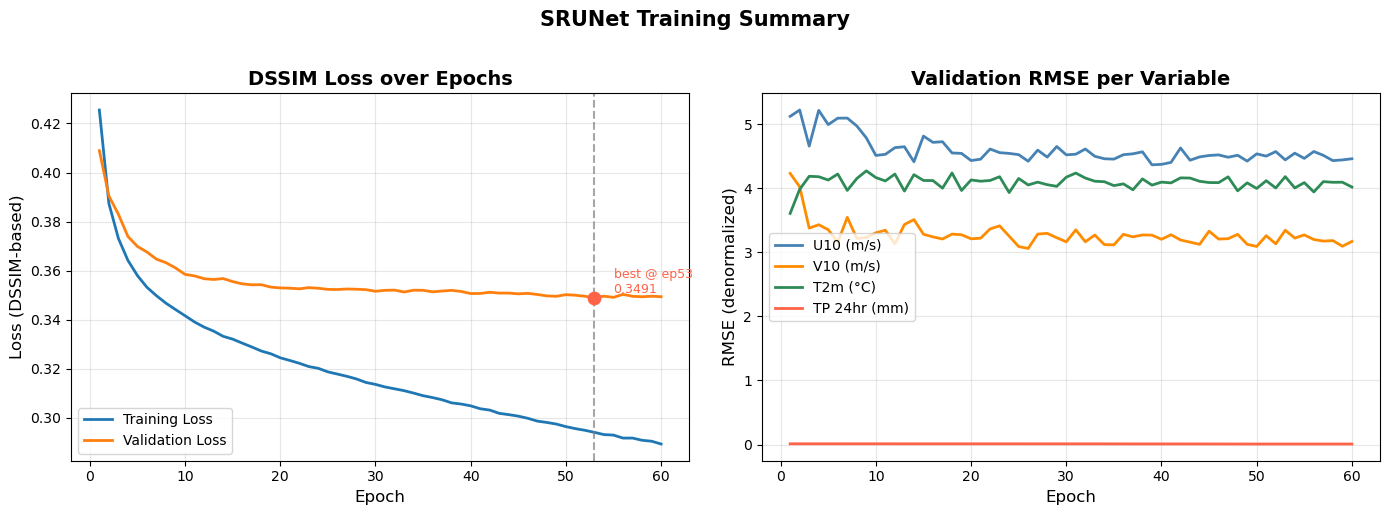


Final Training Loss: 0.289351
Final Validation Loss: 0.349390


In [29]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history["train_loss"]) + 1)

# ── Left: Loss (DSSIM-based) ──
ax1.plot(epochs_range, history["train_loss"], label="Training Loss", linewidth=2)
ax1.plot(epochs_range, history["val_loss"],   label="Validation Loss", linewidth=2)

best_epoch = np.argmin(history["val_loss"]) + 1
best_loss  = min(history["val_loss"])
ax1.axvline(best_epoch, color="gray", linestyle="--", alpha=0.7)
ax1.scatter([best_epoch], [best_loss], color="tomato", zorder=5, s=80)
ax1.annotate(
    f"best @ ep{best_epoch}\n{best_loss:.4f}",
    xy=(best_epoch, best_loss),
    xytext=(best_epoch + 2, best_loss + 0.002),
    fontsize=9, color="tomato",
)

ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss (DSSIM-based)", fontsize=12)
ax1.set_title("DSSIM Loss over Epochs", fontsize=14, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ── Right: Val RMSE per Variable ──
var_colors = {
    VAR_LABELS[0]: "steelblue",
    VAR_LABELS[1]: "darkorange",
    VAR_LABELS[2]: "seagreen",
    VAR_LABELS[3]: "tomato",
}

for var in VAR_LABELS:
    rmse_curve = [m[var]["RMSE"] for m in history["val_metrics"]]
    ax2.plot(epochs_range, rmse_curve, label=var, color=var_colors[var], linewidth=2)

ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("RMSE (denormalized)", fontsize=12)
ax2.set_title("Validation RMSE per Variable", fontsize=14, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle("SRUNet Training Summary", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("srunet_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nFinal Training Loss: {history['train_loss'][-1]:.6f}")
print(f"Final Validation Loss: {history['val_loss'][-1]:.6f}")

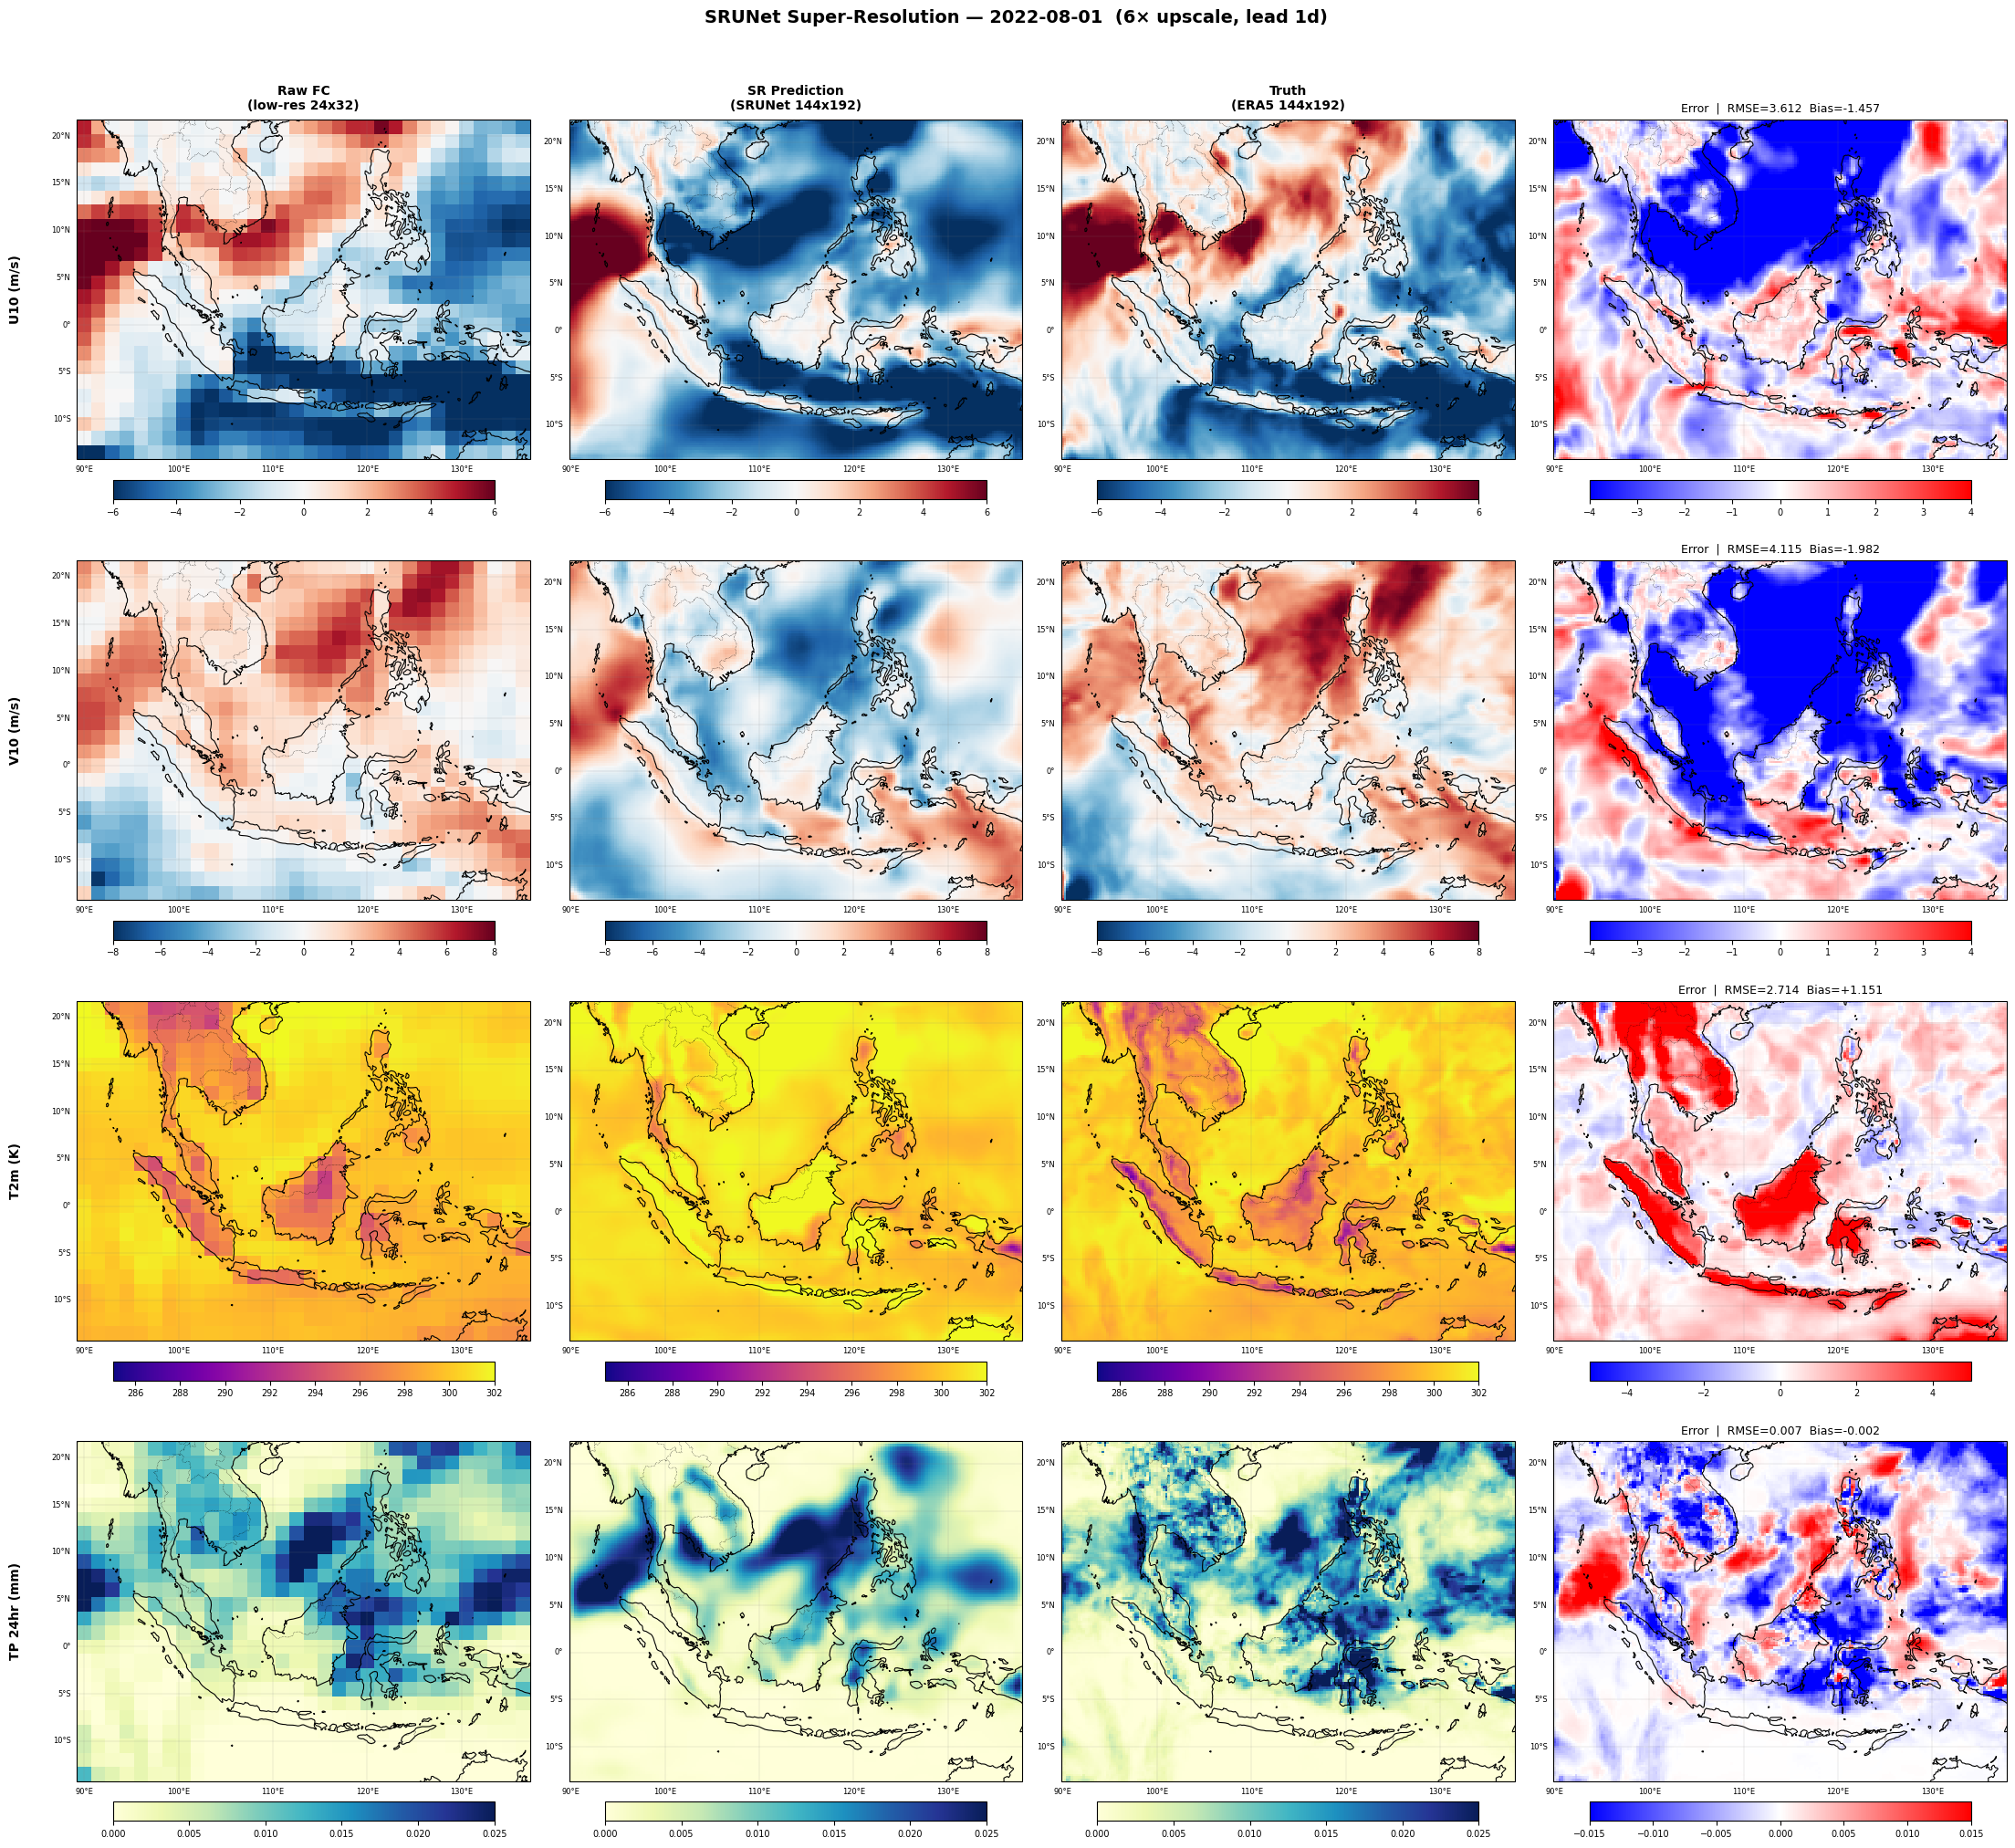

In [30]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch
import numpy as np

# ==============================
# Config — match regrid_correction.ipynb style
# ==============================
VAR_LABELS_VIZ = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]
target_date = np.datetime64("2022-08-01")

# Hardcoded color ranges (consistent across notebooks for head-to-head)
#                   U10    V10    T2m       TP
FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.025]
ERROR_LIM  = [       4,     4,     5,   0.015]

# ==============================
# Find index in test split
# ==============================
test_times = ds_tr_aligned.time.values[n_train + n_val:]
idx = np.where(test_times == target_date)[0]
if len(idx) == 0:
    raise ValueError(
        f"{target_date} not found in test set.\n"
        f"Available range: {test_times[0]} → {test_times[-1]}"
    )
idx = idx[0]

# ==============================
# Get sample & predict
# ==============================
device = next(model.parameters()).device
model.eval()

X_sample = X_test[[idx]].to(device)
Y_sample = Y_test[[idx]]

with torch.no_grad():
    Y_pred_sample = model(X_sample).cpu()

# Denormalize — keep T2m in Kelvin (no K→°C) to match regrid notebook
Y_mu  = norm_stats["Y_mean"]
Y_sig = norm_stats["Y_std"]
X_mu  = norm_stats["X_mean"]
X_sig = norm_stats["X_std"]

X_dn   = denormalize(X_sample.cpu(), X_mu, X_sig)[0]   # (4, 24,  32)
Y_true = denormalize(Y_sample,       Y_mu, Y_sig)[0]   # (4, 144, 192)
Y_pred = denormalize(Y_pred_sample,  Y_mu, Y_sig)[0]   # (4, 144, 192)

# ==============================
# Coordinate arrays
# ==============================
lons_lr = ds_fc_lead.longitude.values   # (32,)
lats_lr = ds_fc_lead.latitude.values    # (24,)
lons_hr = ds_tr_aligned.longitude.values  # (192,)
lats_hr = ds_tr_aligned.latitude.values   # (144,)

# ==============================
# Plot: 4 rows × 4 cols  (matching regrid_correction.ipynb layout)
# cols: Raw FC | Prediction (SR) | Truth (ERA5) | Error
# ==============================
proj   = ccrs.PlateCarree()
n_vars = len(VAR_LABELS_VIZ)

col_titles = [
    "Raw FC\n(low-res 24x32)",
    "SR Prediction\n(SRUNet 144x192)",
    "Truth\n(ERA5 144x192)",
    "Error\n(Pred - Truth)",
]

# Colormaps — same as regrid notebook
cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

fig, axes = plt.subplots(
    n_vars, 4,
    figsize=(22, 5 * n_vars),
    subplot_kw={"projection": proj},
)

for v in range(n_vars):
    # PyTorch (C, H, W) → numpy (H, W)
    raw_v  = X_dn[v].numpy()       # (24,  32)
    pred_v = Y_pred[v].numpy()     # (144, 192)
    true_v = Y_true[v].numpy()     # (144, 192)
    err_v  = pred_v - true_v

    cmap_f = cmaps_field[v]

    # Hardcoded ranges
    vmin = FIELD_VMIN[v]
    vmax = FIELD_VMAX[v]
    elim = ERROR_LIM[v]

    panels = [
        (lons_lr, lats_lr, raw_v,  cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, pred_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, true_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, err_v,  "bwr",  -elim,  elim),
    ]

    for col, (lons, lats, data, cmap, lo, hi) in enumerate(panels):
        ax = axes[v, col]

        # Ensure data shape is (n_lats, n_lons) for pcolormesh
        if data.shape != (len(lats), len(lons)):
            data = data.T

        im = ax.pcolormesh(
            lons, lats, data,
            cmap=cmap, vmin=lo, vmax=hi,
            shading="nearest",
            transform=proj,
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=":")
        ax.add_feature(cfeature.LAND,      facecolor="whitesmoke", zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor="lightcyan",  zorder=0)

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
        gl.top_labels   = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 6}
        gl.ylabel_style = {"size": 6}

        cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046)
        cb.ax.tick_params(labelsize=7)

        if v == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight="bold", pad=8)
        if col == 0:
            ax.text(-0.15, 0.5, VAR_LABELS_VIZ[v], transform=ax.transAxes,
                    fontsize=10, fontweight="bold", va="center", rotation=90)

    # RMSE + bias on error panel
    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    axes[v, 3].set_title(
        f"Error  |  RMSE={rmse:.3f}  Bias={bias:+.3f}",
        fontsize=9, pad=6,
    )

fig.suptitle(
    f"SRUNet Super-Resolution — {str(target_date)[:10]}  (6× upscale, lead {lead_days}d)",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(f"srunet_eval_{str(target_date)[:10]}.png", dpi=150, bbox_inches="tight")
plt.show()

## Aggregate Test Set Evaluation
Per-variable RMSE, MAE, Bias, Correlation, and Skill Score over the **entire** test split.
Baseline = bilinear interpolation (nearest-neighbour upscaled input).

In [ ]:
# ==============================
# Aggregate test-set evaluation
# (Corrected Spatio-Temporal Metrics)
# ==============================
import numpy as np

Y_mu  = norm_stats["Y_mean"]
Y_sig = norm_stats["Y_std"]
X_mu  = norm_stats["X_mean"]
X_sig = norm_stats["X_std"]

# Denormalize predictions and ground truth
y_pred_phys = denormalize(test_preds.clone(), Y_mu, Y_sig).numpy()
y_true_phys = denormalize(test_targets.clone(), Y_mu, Y_sig).numpy()

# Bilinear baseline: upsample raw low-res input to high-res via F.interpolate
# This is the "no model" baseline — just bilinear interpolation
baseline_preds = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        upsampled = F.interpolate(
            X_batch, size=(144, 192), mode="bilinear", align_corners=False
        )
        baseline_preds.append(upsampled)
baseline_preds = torch.cat(baseline_preds, dim=0)

# Denormalize baseline using X stats (it's in X-normalized space)
x_base_phys = denormalize(baseline_preds.clone(), X_mu, X_sig).numpy()

print("\n" + "=" * 100)
print(f"{'Variable':<18} | {'RMSE':>8} | {'MAE':>8} | {'Bias':>8} | {'Corr':>8} | {'Baseline RMSE':>14} | {'Skill':>8}")
print("=" * 100)

for v_idx, v_name in enumerate(VARS):
    # Extract arrays for the specific variable. 
    # Shape becomes (Time/Batch, Height, Width)
    pred_v = y_pred_phys[:, v_idx, :, :]
    true_v = y_true_phys[:, v_idx, :, :]
    base_v = x_base_phys[:, v_idx, :, :]

    # Ensure base_v has same spatial shape as true_v
    if base_v.shape[-2:] != true_v.shape[-2:]:
        base_v = np.transpose(base_v, (0, 2, 1))

    # ---------------------------------------------------------
    # 1. Calculate metrics per grid cell (along axis=0 / time)
    # ---------------------------------------------------------
    rmse_grid = np.sqrt(np.mean((pred_v - true_v) ** 2, axis=0))
    rmse_base_grid = np.sqrt(np.mean((base_v - true_v) ** 2, axis=0))
    
    mae_grid = np.mean(np.abs(pred_v - true_v), axis=0)
    bias_grid = np.mean(pred_v - true_v, axis=0)
    
    # Vectorized Pearson Correlation over time
    # Subtract time-mean for each pixel
    pred_diff = pred_v - np.mean(pred_v, axis=0)
    true_diff = true_v - np.mean(true_v, axis=0)
    
    # Covariance and Variances
    cov = np.sum(pred_diff * true_diff, axis=0)
    var_pred = np.sum(pred_diff ** 2, axis=0)
    var_true = np.sum(true_diff ** 2, axis=0)
    
    # Calculate correlation grid, safely handling division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        corr_grid = cov / np.sqrt(var_pred * var_true)

    # ---------------------------------------------------------
    # 2. Spatially average the grid metrics to get final scalars
    # ---------------------------------------------------------
    # We use nanmean to ignore pixels where correlation might be NaN 
    # (e.g., if a grid cell had zero variance over time)
    rmse = np.nanmean(rmse_grid)
    rmse_base = np.nanmean(rmse_base_grid)
    mae = np.nanmean(mae_grid)
    bias = np.nanmean(bias_grid)
    corr = np.nanmean(corr_grid)

    # Skill score: 1 - (RMSE_model / RMSE_baseline)
    skill = 1.0 - (rmse / rmse_base) if rmse_base > 0 else 0.0

    label = VAR_LABELS[v_idx]
    print(f"{label:<18} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

print("=" * 100)
print("\nSkill > 0 means SRUNet improves over bilinear interpolation baseline.")


Variable           |     RMSE |      MAE |     Bias |     Corr |  Baseline RMSE |    Skill
U10 (m/s)          |   4.0558 |   2.3026 |  -1.4998 |   0.5173 |         4.9395 |  +0.1789
V10 (m/s)          |   3.4760 |   2.0601 |  -1.2724 |   0.5256 |         3.4901 |  +0.0040
T2m (°C)           |   3.2844 |   1.5343 |  +1.1471 |  -0.3513 |         2.3807 |  -0.3796
TP 24hr (mm)       |   0.0094 |   0.0048 |  -0.0016 |   0.6056 |         0.0133 |  +0.2966

Skill > 0 means SRUNet improves over bilinear interpolation baseline.
